# Validation Pipeline Sketch V1

## 0. Imports and Set-Up:

In [1]:
from typing import Type, Any, Optional

import scanpy as sc
import numpy as np
import pandas as pd

from sklearn.base import ClusterMixin
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, jaccard_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

from scipy.optimize import linear_sum_assignment
from scipy.stats import multivariate_normal

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

### 0.1 Data Import:

In [4]:
adata = sc.datasets.ebi_expression_atlas(accession='E-GEOD-98816', filter_boring=True)
adata_vis = sc.datasets.ebi_expression_atlas(accession='E-GEOD-98816', filter_boring=True)
adata.obs.head()

,Sample Characteristic[genotype]
SRR5529430,Cldn5-GFP
SRR5529431,Cldn5-GFP
SRR5529432,Cldn5-GFP
SRR5529433,Cldn5-GFP
SRR5529434,Cldn5-GFP


/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


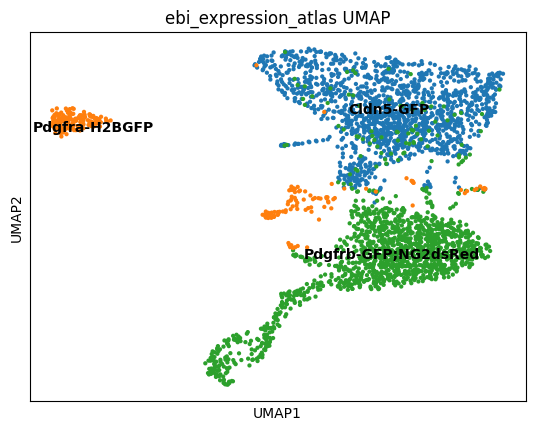

In [5]:
sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)
sc.pp.highly_variable_genes(adata_vis, n_top_genes=1000, subset=True)
sc.pp.scale(adata_vis)
sc.tl.pca(adata_vis, svd_solver='arpack')

sc.pp.neighbors(adata_vis, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata_vis)

sc.pl.umap(
    adata_vis, color='Sample Characteristic[genotype]',
    title='ebi_expression_atlas UMAP',
    legend_loc='on data',
    show=True
)

In [6]:
df_expr = adata.to_df()
df_expr['cell_type'] = adata.obs['Sample Characteristic[genotype]'].values

In [7]:
df_expr.shape

(3186, 28258)

In [8]:
df_expr['cell_type'].value_counts()

cell_type
Pdgfrb-GFP;NG2dsRed    1484
Cldn5-GFP              1445
Pdgfra-H2BGFP           257
Name: count, dtype: int64

In [9]:
df_expr['cell_type'] = pd.factorize(df_expr['cell_type'])[0]

In [10]:
df_expr.describe().T

,count,mean,std,min,25%,50%,75%,max
ENSMUSG00000000001,3186.0,66.615822,143.379898,0.0,0.000000,0.000000,50.75000,1650.000000
ENSMUSG00000000003,3186.0,0.003139,0.114791,0.0,0.000000,0.000000,0.00000,5.000000
ENSMUSG00000000028,3186.0,94.060928,72.213524,0.0,46.633774,79.758419,126.08358,955.594238
ENSMUSG00000000037,3186.0,0.316698,7.246142,0.0,0.000000,0.000000,0.00000,280.000000
ENSMUSG00000000049,3186.0,0.081921,2.647093,0.0,0.000000,0.000000,0.00000,128.000000
...,...,...,...,...,...,...,...,...
ENSMUSG00000118671,3186.0,0.246740,5.108175,0.0,0.000000,0.000000,0.00000,272.132751
ENSMUSG00000118672,3186.0,0.147739,4.639779,0.0,0.000000,0.000000,0.00000,225.000000
ENSMUSG00001074846,3186.0,0.013348,0.383687,0.0,0.000000,0.000000,0.00000,17.000000
ENSMUSG00002076083,3186.0,10.550959,46.827126,0.0,0.000000,0.000000,0.00000,832.584106


In [11]:
X = df_expr.values
n_samples = X.shape[0]

### 0.2 Synthetic Data:

In [3]:
def generate_gaussian_mixture(
    n_samples: int, 
    pi1: float = 0.5, 
    sigma: float = 0.15, 
    mu1: Optional[np.ndarray] = None, 
    mu2: Optional[np.ndarray] = None, 
    seed: Optional[int] = None
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate 2D Gaussian mixture data and compute ground-truth soft labels.

    :param n_samples: number of samples to generate.
    :param sigma: standard deviation of the isotropic Gaussians.
    :param seed: optional random seed.
    
    :return: 
        X: (n_samples, 2) data matrix
        soft_labels: (n_samples, 2) matrix of posterior probabilities
    """
    if seed is not None:
        np.random.seed(seed)

    # Define component means on unit circle
    if mu1 is None:
        mu1 = np.array([1.0, 0.0])
    
    if mu2 is None:
        mu2 = np.array([-1.0, 0.0])
    
    # Mixing proportions
    pi2 = 1 - pi1

    # Covariance matrix (isotropic)
    cov = (sigma ** 2) * np.eye(2)

    # Sample component labels (0 or 1)
    labels = np.random.choice([0, 1], size=n_samples, p=[pi1, pi2])

    # Generate samples
    X = np.array([
        np.random.multivariate_normal(mu1, cov) if label == 0 else
        np.random.multivariate_normal(mu2, cov)
        for label in labels
    ])

    # Compute posterior probabilities
    phi1 = multivariate_normal.pdf(X, mean=mu1, cov=cov)
    phi2 = multivariate_normal.pdf(X, mean=mu2, cov=cov)
    denom = pi1 * phi1 + pi2 * phi2

    theta1 = (pi1 * phi1) / denom
    theta2 = 1.0 - theta1

    soft_labels = np.vstack((theta1, theta2)).T

    return X, soft_labels

In [4]:
X, soft_labels = generate_gaussian_mixture(n_samples=500, sigma=0.5, seed=42)
print("Data shape:", X.shape)
print("Soft labels shape:", soft_labels.shape)
print("First 10 soft labels:\n", soft_labels[: 10])

Data shape: (500, 2)
Soft labels shape: (500, 2)
First 10 soft labels:
 [[9.99914510e-01 8.54901497e-05]
 [1.47987292e-02 9.85201271e-01]
 [9.22431238e-06 9.99990776e-01]
 [1.70672448e-06 9.99998293e-01]
 [9.99997003e-01 2.99740549e-06]
 [7.59047014e-01 2.40952986e-01]
 [9.99469861e-01 5.30139224e-04]
 [5.69953416e-07 9.99999430e-01]
 [3.42455884e-04 9.99657544e-01]
 [5.54340062e-05 9.99944566e-01]]


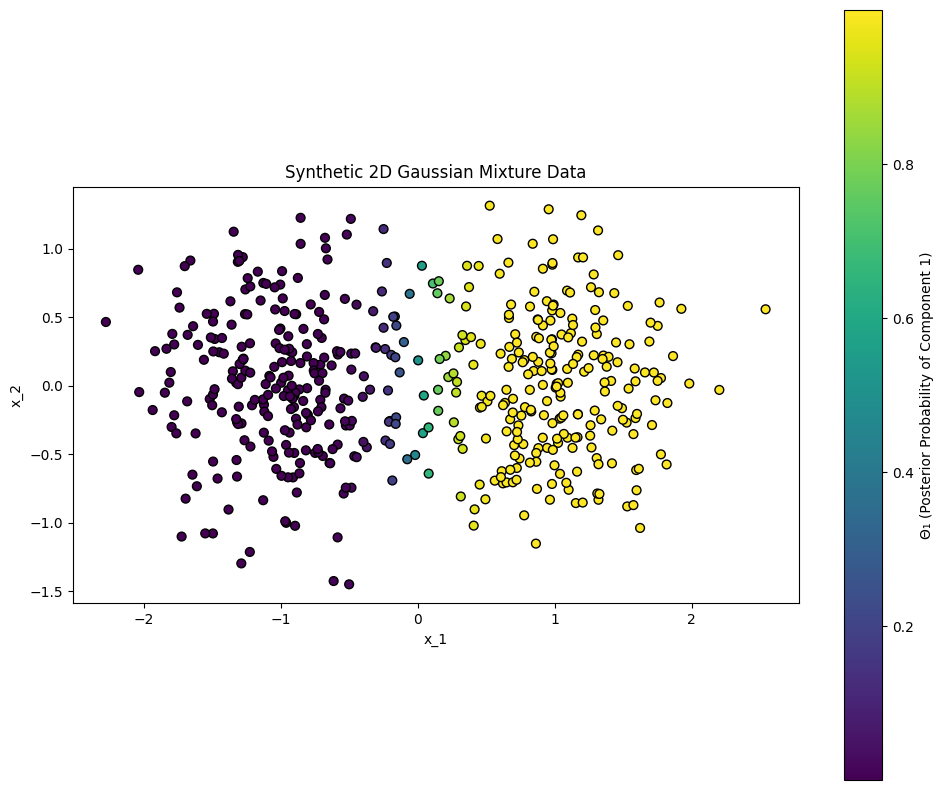

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=soft_labels[:, 0], cmap='viridis', s=40, edgecolors='k')

cbar = fig.colorbar(scatter, ax=ax, label='Θ₁ (Posterior Probability of Component 1)')

ax.set_title("Synthetic 2D Gaussian Mixture Data")
ax.set_xlabel("x_1")
ax.set_ylabel("x_2")
# ax.grid(True)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 1. Helper Functions:

In [6]:
def subsample_indices(n_samples: int, ratio: float = 0.8, random_state: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :param n_samples: total number of samples in data frame.
    :param ratio: ratio for subsampling, between 0 and 1. 
    :param random_state: random seed for rng.
    
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(random_state)
    all_idx = np.arange(n_samples)
    train_size = int(np.float64(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

In [7]:
def cluster_and_get_labels(X_train: np.ndarray, algorithm: Type[ClusterMixin], **cluster_kwargs) -> tuple[np.ndarray, ClusterMixin]:
    """
    fits `algorithm` on X_train, returns an array of cluster labels, length = len(X_train).

    :param X_train: numpy array of shape (n_train, n_features)
    :param algorithm: a clustering class or function (e.g., sklearn.cluster.KMeans)
    :param cluster_kwargs: parameters passed to the clustering constructor, e.g. n_clusters=k, random_state, etc.

    :return:
        labels: 1D array of length n_train, cluster assignments (0..k-1)
        fitted_model: the trained clustering object
    """
    model = algorithm(**cluster_kwargs)
    labels = model.fit_predict(X_train)
    
    return labels, model

In [8]:
def train_rf(X_train: np.ndarray, labels_train: np.ndarray, **rf_kwargs) -> RandomForestClassifier:
    """
    trains a random forest classifier to predict cluster labels from features.
    returns the fitted RandomForestClassifier.
    
    :param X_train: numpy array, shape = (n_train, n_features)
    :param labels_train: 1D array of ints (cluster ids)
    :param rf_kwargs: keyword args for RandomForestClassifier, e.g. n_estimators, max_depth, random_state
    
    :return: fitted RandomForestClassifier
    """
    rf_model = RandomForestClassifier(**rf_kwargs)
    rf_model.fit(X_train, labels_train)
    
    return rf_model

In [9]:
def compute_global_metrics(labels_A: np.ndarray, labels_B: np.ndarray) -> dict[str, float]:
    """
    compute ARI and NMI between two label vectors of equal length.
    
    :param labels_A: 1d array of ints (cluster ids) for first partition
    :param labels_B: 1d array of ints (cluster ids) for second partition
    
    :return: a dict {"ARI": ari_value, "NMI": nmi_value}
    """
    ari = adjusted_rand_score(labels_A, labels_B)
    nmi = normalized_mutual_info_score(labels_A, labels_B)
    
    return {"ARI": ari, "NMI": nmi}

In [10]:
def align_cluster_labels_and_compute_scores(true_labels: np.ndarray, pred_labels: np.ndarray, score_type: str = 'jaccard') -> tuple[list[float], float, float]:
    """
    aligns predicted labels to true labels using Hungarian algorithm, then computes a score (jaccard or f1) for each aligned cluster.
    
    :param true_labels: 1D array of ints (ground-truth or reference cluster IDs)
    :param pred_labels: 1D array of ints (predicted cluster IDs)
    :param score_type: "jaccard" or "f1"
    
    :return:
        per_cluster_scores: list of length = n_clusters, where each element is the jaccard or f1 for that aligned cluster pair.
        median_score: median of per_cluster_scores
        iqr_score: interquartile range of per_cluster_scores
    """
    cm = confusion_matrix(true_labels, pred_labels)  # get confusion matrix, rows: true clusters, cols: predicted clusters
    row_idx, col_idx = linear_sum_assignment(-cm)  # maximize total matches (use -cm as cost)
    alignment = dict(zip(col_idx, row_idx))  # cleate mapping from pred_cluster to "aligned true cluster" via col_idx to row_idx
    
    per_scores = []
    for p_cluster, t_cluster in alignment.items():  # for each aligned cluster pair, compute jaccard or f1
        mask_true = (true_labels == t_cluster)  # get boolean masks
        mask_pred = (pred_labels == p_cluster)
        
        if score_type == 'jaccard':
            score = jaccard_score(mask_true.astype(int), mask_pred.astype(int))
        elif score_type == 'f1':
            score = f1_score(mask_true.astype(int), mask_pred.astype(int))
        else:
            raise ValueError("score_type must be 'jaccard' or 'f1'")
    
        per_scores.append(score)
        
    per_scores = np.array(per_scores)
    median_score = np.median(per_scores)
    iqr_score = np.percentile(per_scores, 97.5) - np.percentile(per_scores, 2.5)
    return per_scores, median_score, iqr_score

In [11]:
def update_consensus_count(C: np.ndarray, labels_full: np.ndarray) -> None:
    """
    increment C[i,j] by 1 for every pair i,j that share the same cluster label.
    
    :param C: consensus matrix.
    :param labels_full: 1D array length = n_samples, where each entry is an integer cluster ID.
    
    :return: None (C is updated in place)
    """
    for cluster_id in np.unique(labels_full):
        members = np.where(labels_full == cluster_id)[0]
        
        for i in members:
            C[i, members] += 1
    
    return None

In [12]:
def compute_sample_entropy(C: np.ndarray) -> np.ndarray:
    """
    compute sample entropy for each row of the input matrix.

    :param C: square numpy array of floats (consensus matrix)
    
    :return: 1-d numpy array of length n containing the average binary entropy of each row (excluding self‐entropies)
    """
    n = C.shape[0]
    entropy_arr = np.zeros(n)
    
    eps = 1e-12
    C_clipped = np.clip(C, eps, 1-eps)
    
    for i in range(n):
        m_i = np.delete(C_clipped[i, :], i)
        h_i = - (m_i * np.log(m_i) + (1-m_i) * np.log(1-m_i))
        
        entropy_arr[i] = np.mean(h_i)
        
    return entropy_arr

In [13]:
def align_to_ref(theta: np.ndarray, ref_labels: np.ndarray) -> np.ndarray:
    """
    align a cluster‐assignment matrix to a fixed reference labeling using Hungarian algorithm.

    :param theta: assignment matrix for one iteration
    :param ref_labels: reference cluster labels for each sample

    :return: permuted assignment matrix aligned to ref_labels
    """
    
    k = theta.shape[1]
    weights = np.zeros((k, k), dtype=float)
    
    for i in range(k):
        idxs = np.where(ref_labels == i)[0]
        weights[i] = theta[idxs].sum(axis=0)
    
    _, col_ind = linear_sum_assignment(-weights)
    
    return theta[:, col_ind]

---
## 2. Main Validation Loop

In [14]:
def run_validation(X: np.ndarray, k: int, algorithm: Type[ClusterMixin] = KMeans, S: int = 100, rho: float = 0.8, rf_kwargs: Optional[dict[str, Any]] = None) -> dict[str, Any]:
    """
    run clustering validation.

    :param X: input data array of shape (n_samples, n_features)
    :param k: number of clusters to fit
    :param algorithm: sklearn clustering class implementing ClusterMixin
    :param S: number of subsampling iterations
    :param rho: subsample ratio in (0,1)
    :param rf_kwargs: keyword args for RandomForestClassifier
    
    :return: dict mapping k to a dict containing:
        'stats': summary metrics (ARI, NMI, jaccard)
        'M': consensus matrix (np.ndarray)
        'H': sample entropy of M
    """
    n_samples = X.shape[0]
    p = X.shape[1]
    ref_cluster = algorithm(n_clusters=k, random_state=0)
    ref_labels = ref_cluster.fit(X).labels_
    
    cluster_kwargs = {'n_clusters': k, 'random_state': None}
    
    if rf_kwargs is None:
        rf_kwargs = {'n_estimators': 300, 'max_depth': p, 'max_features': np.round(np.sqrt(p)), 'random_state': None}

    # initializing score arrays
    global_ari_scores = []
    # global_nmi_scores = []
    cluster_medians = []
    cluster_iqrs = []

    C = np.zeros((n_samples, n_samples), dtype=int)  # initialize consensus count matrix
    
    cluster_assignment_arr = []


    for s in tqdm(range(S), desc=f'validation iterations for k = {k}'):
        # 1. subsample
        A_train_idx, A_test_idx = subsample_indices(n_samples, ratio=rho, random_state=s)
        B_train_idx, B_test_idx = subsample_indices(n_samples, ratio=rho, random_state=s+S)
        
        # 2. cluster on A_train and B_train
        cluster_kwargs["random_state"] = s
        labels_A_train, _ = cluster_and_get_labels(X[A_train_idx], algorithm, **cluster_kwargs)
        cluster_kwargs["random_state"] = s + S
        labels_B_train, _ = cluster_and_get_labels(X[B_train_idx], algorithm, **cluster_kwargs)
        
        # 3. train random forest classifier
        rf_kwargs["random_state"] = s
        rf_A = train_rf(X[A_train_idx], labels_A_train, **rf_kwargs)
        rf_kwargs["random_state"] = s + S
        rf_B = train_rf(X[B_train_idx], labels_B_train, **rf_kwargs)
        
        # 4. predict labels on test sets
        labels_A_test_pred = rf_A.predict(X[A_test_idx])
        labels_B_test_pred = rf_B.predict(X[B_test_idx])
        
        # 5. predict labels on cross sets
        labels_A_on_B = rf_A.predict(X[B_train_idx])
        labels_B_on_A = rf_B.predict(X[A_train_idx])
        
        # 6. compute global metrics
        gm1 = compute_global_metrics(labels_A_test_pred, labels_B_test_pred)
        gm2 = compute_global_metrics(labels_A_on_B, labels_B_train)
        gm3 = compute_global_metrics(labels_B_on_A, labels_A_train)
        
        avg_ari = np.mean([gm1["ARI"], gm2["ARI"], gm3["ARI"]])
        # avg_nmi = np.mean([gm1["NMI"], gm2["NMI"], gm3["NMI"]])
        
        global_ari_scores.append(avg_ari)
        # global_nmi_scores.append(avg_nmi)
        
        # 7. compute cluster metrics
        _, median_jaccard, iqr_jaccard = align_cluster_labels_and_compute_scores(labels_A_test_pred, labels_B_test_pred, score_type='jaccard')
        cluster_medians.append(median_jaccard)
        cluster_iqrs.append(iqr_jaccard)
        
        # 8. update consensus matrix
        full_labels, _ = cluster_and_get_labels(X, algorithm, **cluster_kwargs)
        update_consensus_count(C, full_labels)
        
        # 9. update cluster assignment array
        theta_A = np.zeros((n_samples, k), dtype=int)
        theta_A[A_train_idx, labels_A_train] = 1
        theta_A[A_test_idx, labels_A_test_pred] = 1
        theta_B = np.zeros((n_samples, k), dtype=int)
        theta_B[B_train_idx, labels_B_train] = 1
        theta_B[B_test_idx, labels_B_test_pred] = 1
        
        theta = (theta_A + theta_B) / 2
        theta = align_to_ref(theta, ref_labels)
        cluster_assignment_arr.append(theta)
    # end for
    
    
    C = C/S
    entropy_arr = compute_sample_entropy(C)
    
    theta_avg = np.mean(cluster_assignment_arr, axis=0)

    # collect summary statistics
    stats = {
        "mean_ari": np.mean(global_ari_scores),
        "std_ari": np.std(global_ari_scores),
        # "mean_nmi": np.mean(global_nmi_scores),
        # "std_nmi": np.std(global_nmi_scores),
        "median_jaccard": np.median(cluster_medians),
        "iqr_jaccard": np.median(cluster_iqrs),
    }
    
    # return results
    return {"stats": stats, "C": C, "entropy_arr": entropy_arr, "theta": theta_avg}

In [24]:
K = 5
results_by_k = {}

for k in range(2, K+1):
    results_by_k[k] = run_validation(X=X, k=k)

validation iterations for k = 5:   0%|          | 0/100 [00:00<?, ?it/s]/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
validation iterations for k = 5:   5%|▌         | 5/100 [00:01<00:33,  2.87it/s]/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
validation iterations for k = 5:   6%|▌         | 6/100 [00:02<00:32,  2.92it/s]/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/met

---
## 3. Analysis of Results:

In [25]:
ks = sorted(results_by_k.keys())

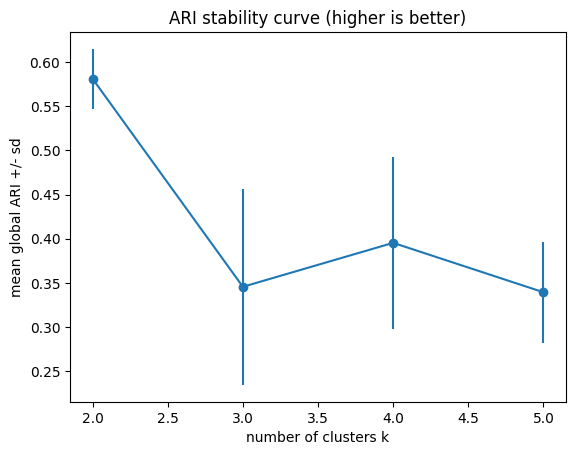

In [26]:
means = [results_by_k[k]['stats']['mean_ari'] for k in ks]
stds = [results_by_k[k]['stats']['std_ari'] for k in ks]

plt.errorbar(ks, means, yerr=stds, fmt='-o')
plt.xlabel('number of clusters k')
plt.ylabel('mean global ARI +/- sd')
plt.title('ARI stability curve (higher is better)')
plt.show()

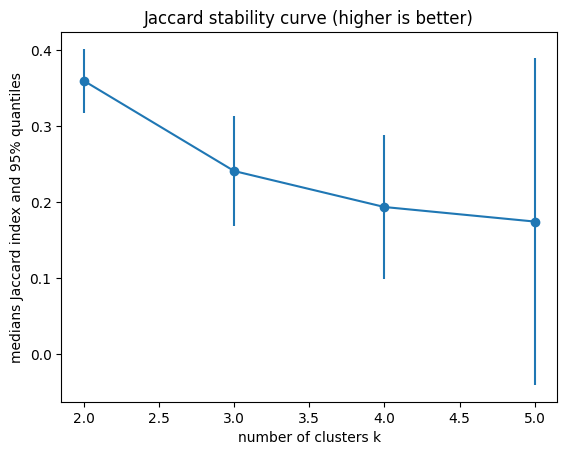

In [27]:
medians = [results_by_k[k]['stats']['median_jaccard'] for k in ks]
iqr = [results_by_k[k]['stats']['iqr_jaccard'] for k in ks]

plt.errorbar(ks, medians, yerr=iqr, fmt='-o')
plt.xlabel('number of clusters k')
plt.ylabel('medians Jaccard index and 95% quantiles')
plt.title('Jaccard stability curve (higher is better)')
plt.show()

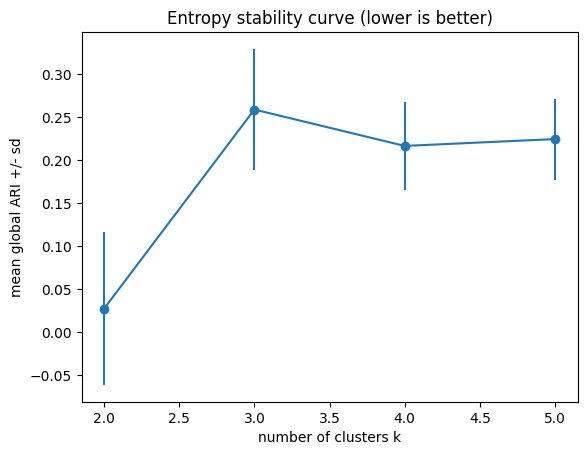

In [28]:
means = [np.mean(results_by_k[k]['entropy_arr']) for k in ks]
stds = [np.std(results_by_k[k]['entropy_arr']) for k in ks]

plt.errorbar(ks, means, yerr=stds, fmt='-o')
plt.xlabel('number of clusters k')
plt.ylabel('mean global ARI +/- sd')
plt.title('Entropy stability curve (lower is better)')
plt.show()

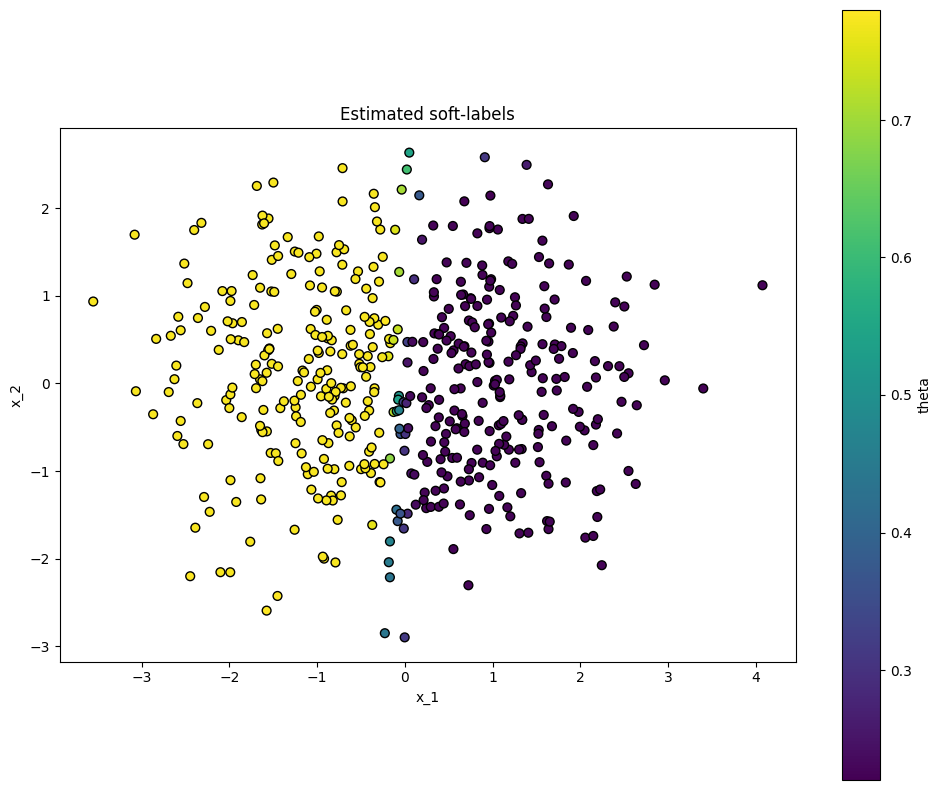

In [29]:
fig2, ax2 = plt.subplots(figsize=(10, 8))
scatter2 = ax2.scatter(
    X[:, 0], X[:, 1],
    c=results_by_k[2]['theta'][:, 0],
    cmap='viridis',
    s=40,
    edgecolors='k'
)

cbar2 = fig2.colorbar(scatter2, ax=ax2, label='theta')
ax2.set_title(f"Estimated soft‐labels")
ax2.set_xlabel("x_1")
ax2.set_ylabel("x_2")
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()

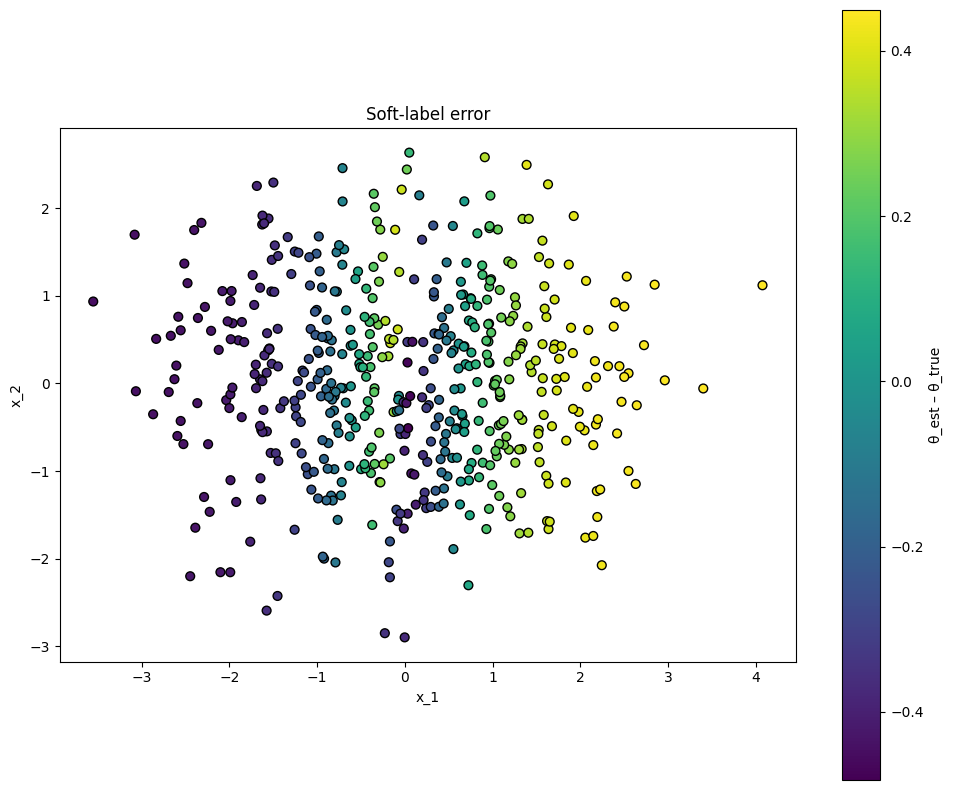

In [30]:
theta_est = results_by_k[2]['theta']
theta_est_flipped = theta_est[:, [1, 0]]

diff_mag = np.diff(theta_est_flipped - soft_labels, axis=1)

fig2, ax2 = plt.subplots(figsize=(10, 8))
scatter2 = ax2.scatter(
    X[:, 0], X[:, 1],
    c=diff_mag,
    cmap='viridis',
    s=40,
    edgecolors='k'
)

cbar2 = fig2.colorbar(scatter2, ax=ax2, label='θ_est – θ_true')
ax2.set_title(f"Soft‐label error")
ax2.set_xlabel("x_1")
ax2.set_ylabel("x_2")
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()

validation iterations for k = 2: 100%|██████████| 100/100 [00:32<00:00,  3.08it/s]


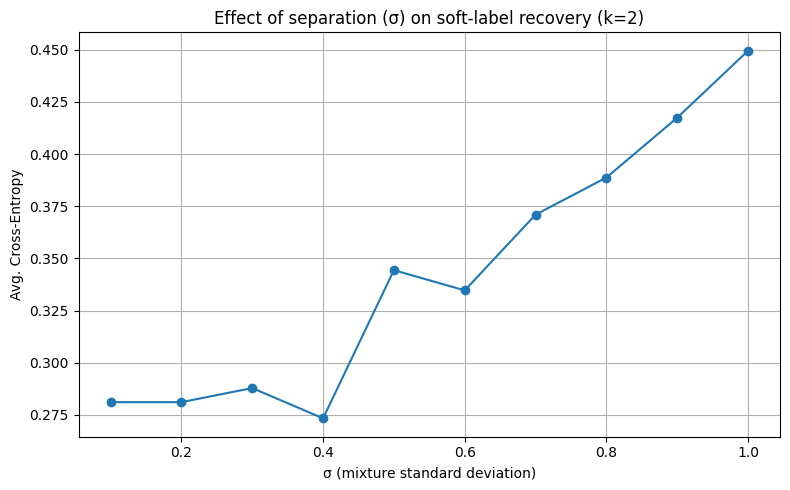

In [31]:
sigma_list = np.linspace(0.1, 1, 10)

mean_ce = []

for sigma in sigma_list:
    X, soft_labels = generate_gaussian_mixture(n_samples=500, sigma=sigma, seed=42)

    result = run_validation(X=X, k=2)
    theta_est = result['theta']

    corr = np.corrcoef(theta_est[:,0], soft_labels[:,0])[0,1]  # align clusters
    if corr < 0:
        theta_est = theta_est[:, ::-1]

    eps = 1e-12
    ce = -(soft_labels * np.log(theta_est+eps)).sum(axis=1).mean()
    mean_ce.append(ce)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(sigma_list, mean_ce, marker='o', linestyle='-')
ax.set_xlabel("σ (mixture standard deviation)")
ax.set_ylabel("Avg. Cross-Entropy")
ax.set_title("Effect of separation (σ) on soft‐label recovery (k=2)")
ax.grid(True)
plt.tight_layout()
plt.show()